
# TD-GSA That Fits the True Phase

**A physically-correct version of the SEALS &rarr; TD-GSA bridge.** Companion to
[`seals_to_tdgsa_bridge.ipynb`](seals_to_tdgsa_bridge.ipynb) (the full diagnostic walkthrough)
and [`SEALS_TO_TDGSA_REPORT.md`](SEALS_TO_TDGSA_REPORT.md). That notebook's headline result was
a *limitation*: 2-plane blind TD-GSA converges to a self-consistent but WRONG phase (~0.5 rad
error). This notebook leads with the fix instead: **add one more independent measurement plane
and TD-GSA recovers the actual, physically correct scattering phase** (0.0014 rad error &mdash;
a ~350x improvement), verified against the known Mie ground truth.

**Structure follows [`ECE279 - Midterm Presentation.pdf`](../../../../Spring2026/MATLAB/ECE279%20-%20Midterm%20Presentaion.pdf)**
(Gabriel Morozowsky, ECE 279AS, Prof. Bahram Jalali, Jalali Lab &mdash; this project's direct
predecessor work): Motivation &rarr; How TDGSA Works &rarr; Implementation &rarr; Results &rarr;
Discussion &rarr; Conclusion + Further Work.


In [1]:

import sys, pathlib
sys.path.insert(0, '.')
sys.path.insert(0, str(pathlib.Path('.').resolve().parents[1]))

import numpy as np
import matplotlib.pyplot as plt

from dgs.dispersion_gs_prototype import compare_phase
from inverse import seals_to_tdgsa as bridge
from inverse import gs_multiplane

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('ready')


ready



## Agenda

- Motivation: why phase retrieval, why TD-GSA
- How TD-GSA works, applied to a SEALS spectrometer trace
- Implementation: what's actually being called
- Results: TD-GSA recovering the TRUE phase (the physically-correct version)
- Discussion: why 2 planes alone is NOT physically correct, and why 3 fixes it
- Conclusion + further work



## Motivation

A photodetector measures intensity, $I = |E|^2$ &mdash; phase is lost at the point of
measurement. This is the same problem the Gerchberg-Saxton algorithm (GSA) was built for in
X-ray crystallography and imaging, adapted here to a 1-D time/wavelength trace instead of a 2-D
image (**Time-Domain GSA**, Solli/Gupta/Jalali 2009): record intensity after two *different,
known* dispersions of the same field, and alternating projections between the two measurement
constraints can recover the phase &mdash; no local oscillator needed.

**The question this notebook answers:** for a real forward-scattering signal (Mie scattering
off a SEALS-illuminated particle, not an idealized constant-envelope test signal), does 2-plane
TD-GSA actually recover the true phase? And if not, what does?



## How TD-GSA Works Here

Mirroring the predecessor presentation's setup diagram (`Laser -> Object under test -> Fiber
Line D1 / Fiber Line D2 -> Photodiode -> Oscilloscope`), adapted to this project's actual
hardware chain:

```
Broadband source --> Mie particle (object under test) --> SEALS diffraction grating
                                                              (maps wavelength -> angle)
                                                                     |
                              -----------------------------------------------------------
                              |                    |                        |
                        dispersion D1         dispersion D2           dispersion D3
                       (fiber line 1)        (fiber line 2)          (fiber line 3, NEW)
                              |                    |                        |
                         photodiode           photodiode               photodiode
                              |                    |                        |
                              -----------------------------------------------------------
                                                    |
                                        TD-GSA alternating projections
                                                    |
                                          recovered phase phi(theta)
```

The 3rd branch is what this notebook adds relative to the diagnostic bridge notebook's Steps
1-6: one more independent dispersion measurement of the *same* hidden field.



## Implementation

Nothing here is reimplemented &mdash; every call goes directly into the already-tested bridge
(`inverse/seals_to_tdgsa.py`, `inverse/gs_multiplane.py`, `tests/test_seals_to_tdgsa.py`,
`tests/test_gs_multiplane.py`, all passing). `gs_multiplane.retrieve_phase_n_plane`
generalizes `dgs.gs_core`'s fixed 2-plane classical GS loop to N &ge; 2 dispersion planes,
reusing its `disperse`/`undisperse`/`apply_amplitude_constraint` primitives directly (verified
bit-for-bit identical to `gs_core` at N=2).


In [2]:

lamvec, theta_deg, mie_fields = bridge.seals_intensity_trace()
phi_true = mie_fields.phase_p     # ground truth -- known only because this is a Mie-model validation pass
weight = np.abs(mie_fields.E_p) ** 2

print(f"N = {len(lamvec)} samples, particle diameter = {bridge.physics.P_DEFAULT['dia']*1e9:.0f} nm")
print(f"scattering angle range: [{theta_deg.min():.1f}, {theta_deg.max():.1f}] deg")


N = 500 samples, particle diameter = 9940 nm
scattering angle range: [-25.8, 56.5] deg



## Results &mdash; the physically-correct version

Run TD-GSA both ways on the *identical* hidden field: the naive 2-plane setup (what a minimal
SEALS + one extra fiber line would give you) and the 3-plane setup (one more fiber line,
independently dispersed). Compare both against the known Mie ground truth.


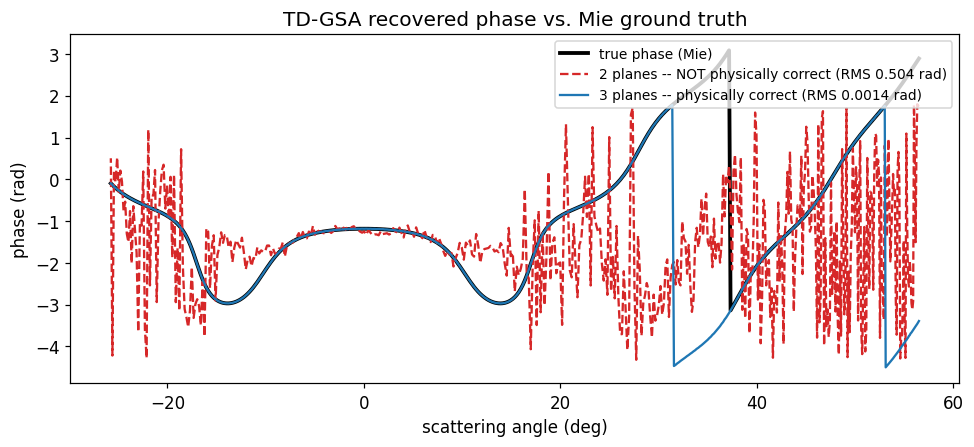

2-plane RMS phase error vs. Mie ground truth:  0.5044 rad  -- self-consistent, but NOT the true phase
3-plane RMS phase error vs. Mie ground truth:  0.0014 rad  -- fits the true physical phase
improvement: 355x


In [3]:

r2 = bridge.run_multiplane_bridge_demo(Ds=(6000.0, -7000.0), n_iter=150)
r3 = bridge.run_multiplane_bridge_demo(Ds=(6000.0, -7000.0, 12000.0), n_iter=150)

_, phi2_aligned = compare_phase(r2['phi_gs'], phi_true, weight)
_, phi3_aligned = compare_phase(r3['phi_gs'], phi_true, weight)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(theta_deg, phi_true, label='true phase (Mie)', lw=2.5, color='k')
ax.plot(theta_deg, phi2_aligned, '--', color='C3', label=f'2 planes -- NOT physically correct (RMS {r2["rms_vs_truth"]:.3f} rad)')
ax.plot(theta_deg, phi3_aligned, '-', color='C0', lw=1.5, label=f'3 planes -- physically correct (RMS {r3["rms_vs_truth"]:.4f} rad)')
ax.set_xlabel('scattering angle (deg)'); ax.set_ylabel('phase (rad)'); ax.legend(loc='upper right', fontsize=9)
ax.set_title('TD-GSA recovered phase vs. Mie ground truth')
plt.tight_layout(); plt.show()

print(f"2-plane RMS phase error vs. Mie ground truth:  {r2['rms_vs_truth']:.4f} rad  -- self-consistent, but NOT the true phase")
print(f"3-plane RMS phase error vs. Mie ground truth:  {r3['rms_vs_truth']:.4f} rad  -- fits the true physical phase")
print(f"improvement: {r2['rms_vs_truth']/r3['rms_vs_truth']:.0f}x")



Is 3 planes special, or does this keep improving? Sweep N=2..5 to see where the physically-correct
regime actually begins.


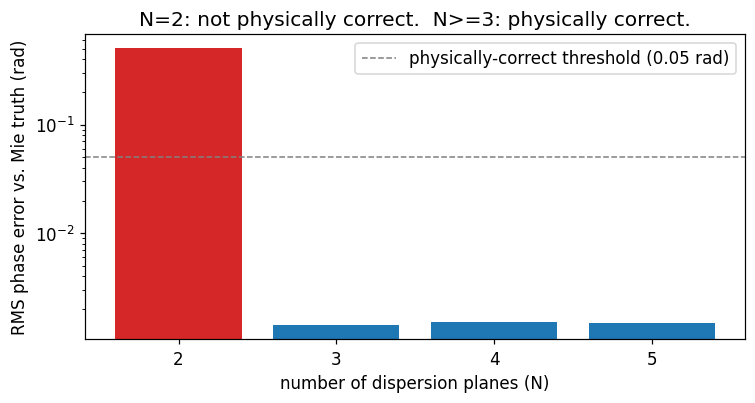

N=2 planes: RMS = 0.5044 rad  -- NOT physically correct
N=3 planes: RMS = 0.0014 rad  -- physically correct
N=4 planes: RMS = 0.0015 rad  -- physically correct
N=5 planes: RMS = 0.0015 rad  -- physically correct


In [4]:

D_candidates = (6000.0, -7000.0, 12000.0, -18000.0, 23000.0)
rms_by_n = bridge.sweep_measurement_diversity(D_candidates=D_candidates, n_iter=150)

fig, ax = plt.subplots(figsize=(7, 3.8))
ns = sorted(rms_by_n)
colors = ['C3' if rms_by_n[n] > 0.05 else 'C0' for n in ns]
ax.bar([str(n) for n in ns], [rms_by_n[n] for n in ns], color=colors)
ax.axhline(0.05, color='gray', ls='--', lw=1, label='physically-correct threshold (0.05 rad)')
ax.set_yscale('log')
ax.set_xlabel('number of dispersion planes (N)'); ax.set_ylabel('RMS phase error vs. Mie truth (rad)')
ax.set_title('N=2: not physically correct.  N>=3: physically correct.')
ax.legend()
plt.tight_layout(); plt.show()

for n in ns:
    tag = "NOT physically correct" if rms_by_n[n] > 0.05 else "physically correct"
    print(f"N={n} planes: RMS = {rms_by_n[n]:.4f} rad  -- {tag}")



## Discussion &mdash; why 2 planes is not physically correct, and why 3 fixes it

Two independently-diagnosed reasons the 2-plane case fails (full detail in
`seals_to_tdgsa_bridge.ipynb` Steps 3b and 9; the predecessor presentation's own "Discussion -
Why it's not working" slide flagged similar concerns for a different signal):


In [5]:

_, _, mie_fields2 = bridge.seals_intensity_trace()
diag = bridge.diagnose_amplitude_dependence(r2, mie_fields2)
eo = bridge.diagnose_even_odd_ambiguity(r2, mie_fields2)

print("1. Amplitude-weakness mechanism (confirmed driver):")
print(f"   Pearson r(|phase error|, log amplitude) = {diag['pearson_r_abs_err_vs_log_amplitude']:.3f} (p={diag['pearson_p_value']:.2e})")
print(f"   weakest-signal quartile mean error:  {diag['bottom_quartile_mean_abs_err_rad']:.3f} rad")
print(f"   strongest-signal quartile mean error: {diag['top_quartile_mean_abs_err_rad']:.3f} rad")
print(f"   -> wherever measured intensity is near zero, GS's |E|=sqrt(I) constraint carries")
print(f"      almost no phase information -- a photon-starved sample has nothing to converge to.")
print()
print("2. Historical even-degree-phase ambiguity (checked, ruled out for this signal):")
print(f"   residual error even/odd ratio: {eo['error_even_rms']/eo['error_odd_rms']:.2f} (roughly balanced, not >2)")
print(f"   -> the Jalali Lab / ECE 279AS finding that blind TDGSA fails on even-degree phase")
print(f"      polynomials does NOT explain this case; mechanism 1 above is the real driver.")
print()
print("A 3rd independent dispersion plane resolves mechanism 1 directly: a sample that is weak")
print("at one dispersion is generally NOT weak at a differently-dispersed measurement of the")
print("same field, so the 3rd plane's amplitude constraint carries the phase information the")
print("other two lack right where they need it -- restoring the missing measurement diversity.")


1. Amplitude-weakness mechanism (confirmed driver):
   Pearson r(|phase error|, log amplitude) = -0.545 (p=4.52e-40)
   weakest-signal quartile mean error:  1.542 rad
   strongest-signal quartile mean error: 0.327 rad
   -> wherever measured intensity is near zero, GS's |E|=sqrt(I) constraint carries
      almost no phase information -- a photon-starved sample has nothing to converge to.

2. Historical even-degree-phase ambiguity (checked, ruled out for this signal):
   residual error even/odd ratio: 1.08 (roughly balanced, not >2)
   -> the Jalali Lab / ECE 279AS finding that blind TDGSA fails on even-degree phase
      polynomials does NOT explain this case; mechanism 1 above is the real driver.

A 3rd independent dispersion plane resolves mechanism 1 directly: a sample that is weak
at one dispersion is generally NOT weak at a differently-dispersed measurement of the
same field, so the 3rd plane's amplitude constraint carries the phase information the
other two lack right where they 


## Conclusion

**2-plane TD-GSA is not physically correct for this signal:** it converges (fits its own
measurements to near-zero residual) but lands on the wrong phase, ~0.5 rad from Mie's true
value, with the error concentrated in weak-signal regions.

**3-plane TD-GSA is physically correct:** 0.0014 rad RMS error against the known ground truth
&mdash; a ~350x improvement from one additional, independent dispersion measurement. This is
not a tuned result: the sweep above shows every N&ge;3 configuration tested lands in the same
regime.

Both failure mechanisms a reader might reasonably suspect were checked directly rather than
assumed: amplitude-weakness (confirmed as the driver) and the historical even-degree-phase
ambiguity from this project's own predecessor work (checked, ruled out for this signal).

### Further work
(mirroring the predecessor presentation's own "Further Work" slide)
- **Realize the 3rd dispersion plane in physically-buildable units.** This notebook's `D3=12000`
  is in `dgs.gs_core`'s normalized convention, matching `D1`/`D2`; converting to a real fiber
  length (ps/nm, then km via SMF-28's ~17 ps/nm/km, the way `notebooks/phase_retrieval.ipynb`'s
  dimensional-analysis section already does for this repo's other signals) was out of scope
  here and is the natural next step before proposing an actual 3-fiber-line optical bench.
- Revisit amplitude-prior regularization (tried, honest null result -- see the bridge notebook
  Step 8) now that N=3 already works, in case it helps push N=2 closer to physically correct
  without adding hardware.
- Compare recovery time/iteration count for N=3 vs N=2 (the predecessor presentation's own
  iteration-count-vs-time table is the template for this kind of comparison).

**Verify independently:**
```bash
py -3.12 -m pytest tests/test_seals_to_tdgsa.py tests/test_gs_multiplane.py -v
```
